In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Dense, Flatten
from keras import Sequential
from keras.applications.vgg16 import VGG16

In [2]:
conv_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(150 , 150 , 3)
)

In [3]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
model = Sequential()

model.add(conv_base)
model.add(Flatten())
model.add(Dense(256 , activation='relu'))
model.add(Dense(1 , activation='sigmoid'))

In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 16,812,353 (64.13 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
conv_base.trainable = False

In [7]:
# generators

train_ds = keras.utils.image_dataset_from_directory(
    directory = 'CatDogClassification/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (150 , 150)
)
validation_ds = keras.utils.image_dataset_from_directory(
    directory = 'CatDogClassification/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (150 , 150)
)

Found 557 files belonging to 2 classes.
Found 140 files belonging to 2 classes.


In [8]:
# Normalize

def process(image , label):
    image = tf.cast(image/255. , tf.float32)
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)


In [11]:
model.compile(optimizer='adam' , loss = 'binary_crossentropy' , metrics=['accuracy'])


In [12]:
history = model.fit(train_ds , epochs=10 , validation_data = validation_ds)

Epoch 1/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.6822 - loss: 0.8045 - val_accuracy: 0.7214 - val_loss: 0.5805
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 49s 3s/step - accuracy: 0.8707 - loss: 0.2754 - val_accuracy: 0.7357 - val_loss: 0.5762
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 46s 3s/step - accuracy: 0.9264 - loss: 0.1798 - val_accuracy: 0.7643 - val_loss: 0.4535
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 45s 3s/step - accuracy: 0.9767 - loss: 0.0999 - val_accuracy: 0.7643 - val_loss: 0.5176
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.9838 - loss: 0.0728 - val_accuracy: 0.7500 - val_loss: 0.5309
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.9982 - loss: 0.0455 - val_accuracy: 0.7571 - val_loss: 0.5217
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 47s 3s/step - accuracy: 1.0000 - loss: 0.0326 - val_accuracy: 0.7571 - val_loss: 0.5427
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 1.0000 - loss: 0.0220 - val_accuracy: 0.7571 - val_loss:

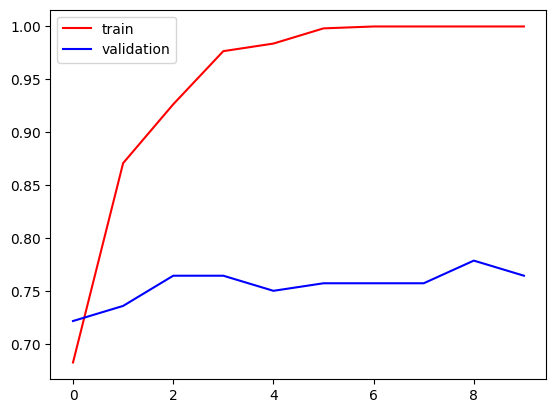

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

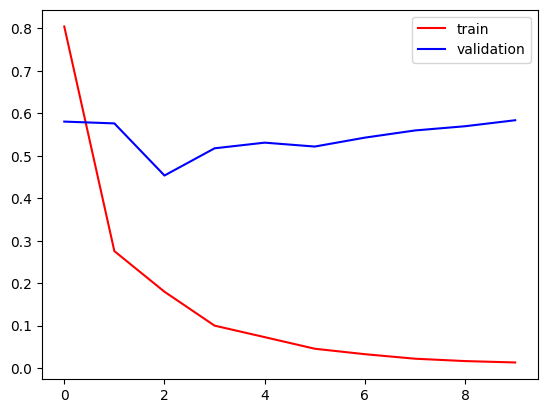

In [14]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()